# 0. Dataset Structure

To ground our simulations, we use two real-world datasets:

### MovieLens (ml-latest-small)
*   **movies.csv**: Contains `movieId`, `title`, and `genres`.
*   **ratings.csv**: Contains `userId`, `movieId`, `rating`, and `timestamp`.

### Amazon Beauty
*   **amazon_beauty.json**: Contains reviews with `reviewerID`, `asin`, `overall` (rating), `reviewText`, etc.


In [1]:
import pandas as pd
import json

# Load and display the structure of the datasets
try:
    movies = pd.read_csv('../data/interim/movies.csv')
    ratings = pd.read_csv('../data/interim/ratings.csv')
    # JSON Lines format for amazon beauty
    beauty = pd.read_json('../data/interim/amazon_beauty.json', lines=True)

    print("=== MovieLens Movies ===")
    print(movies.head(3))
    print("\n=== MovieLens Ratings ===")
    print(ratings.head(3))
    print("\n=== Amazon Beauty Reviews ===")
    print(beauty[['reviewerID', 'asin', 'overall', 'reviewText']].head(3))
except Exception as e:
    print(f"Error loading data: {e}")

=== MovieLens Movies ===
   movieId                    title  \
0        1         Toy Story (1995)   
1        2           Jumanji (1995)   
2        3  Grumpier Old Men (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  

=== MovieLens Ratings ===
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224

=== Amazon Beauty Reviews ===
       reviewerID        asin  overall  \
0  A1YJEY40YUW4SE  7806397051        1   
1   A60XNB876KYML  7806397051        3   
2  A3G6XNM240RMWA  7806397051        4   

                                          reviewText  
0  Very oily and creamy. Not at all what I expect...  
1  This palette was a decent price and I was look...  
2  The texture of this concealer pallet is fantas...  


# Multi-Agent Recommender System: Concepts & Architecture

This notebook provides a pedagogical explanation of the core components of the project:
1. **Data & Simulations**: How real-world data feeds into the simulation environment.
2. **Experiment Protocols**: The standardized ways we test our hypotheses.
3. **Markov Chain Analysis**: How we analyze the long-term behavior of the system.


## 1. Connecting Simulations and Data

In this project, we bridge the gap between static datasets (like MovieLens) and dynamic Reinforcement Learning (RL) simulations using **Adapters**.

### The Concept
A typical RL simulation needs an **Environment** that provides rewards. Instead of using a purely synthetic environment, we create a **Reward Landscape** derived from real data.

*   **X-Axis (Contexts)**: We cluster users into groups based on their behavior (e.g., genre preferences). Each cluster becomes a "Context".
*   **Y-Axis (Recommendations)**: We select the top-N most popular items (e.g., movies). These are the actions available to the Recommender.
*   **Z-Axis (Reward)**: The average rating given by users in a specific cluster to a specific item becomes the expected reward.

### Visualization
The code below generates a synthetic "Reward Landscape" to illustrate what the `MovieLensEnvironmentAdapter` constructs.

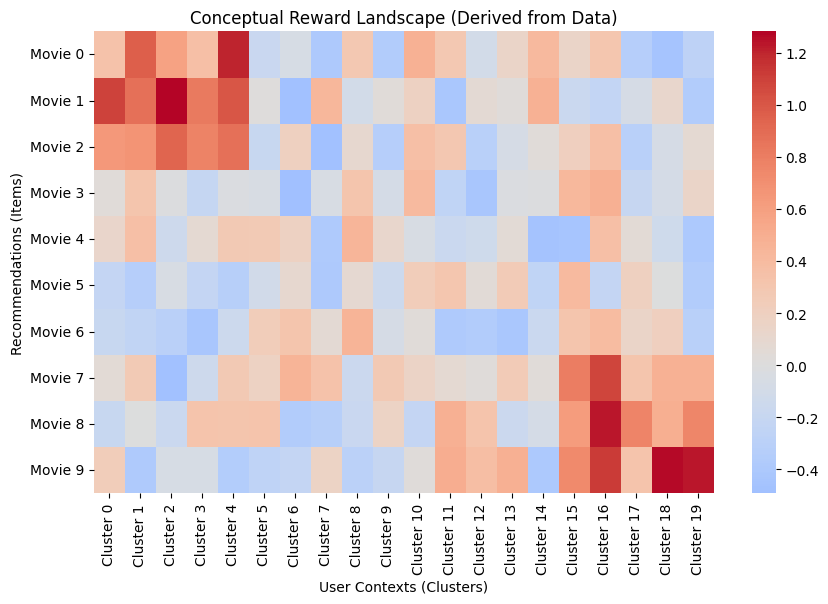

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Simulate a Reward Landscape associated with MovieLensAdapter
n_contexts = 20  # User Clusters (e.g., "Action Lovers", "Romance Fans")
n_items = 10     # Top Movies

# Create a synthetic landscape
# Represents average ratings (normalized to -1 to 1 for the simulation)
landscape = np.random.uniform(-0.5, 0.5, (n_items, n_contexts))

# Add some structure (Action lovers like Action movies)
# Context 0-5 (Action Fans) like Items 0-3 (Action Movies)
landscape[0:3, 0:5] += 0.8

# Context 15-20 (Romance Fans) like Items 7-10 (Romance Movies)
landscape[7:10, 15:20] += 0.8

plt.figure(figsize=(10, 6))
sns.heatmap(landscape, cmap="coolwarm", center=0, 
            xticklabels=[f"Cluster {i}" for i in range(n_contexts)],
            yticklabels=[f"Movie {i}" for i in range(n_items)])
plt.title("Conceptual Reward Landscape (Derived from Data)")
plt.xlabel("User Contexts (Clusters)")
plt.ylabel("Recommendations (Items)")
plt.show()

### 1.1 Real-World Data Clusters

While the above concept uses synthetic clusters, we can derive **actual user clusters** from the MovieLens data we loaded in Section 0. By analyzing which genres each user watches, we can group them into behaviors like "Action Fans" or "Drama Lovers".

The following code performs **K-Means Clustering** on the user-genre matrix and visualizes the results using **PCA** dimensionality reduction.

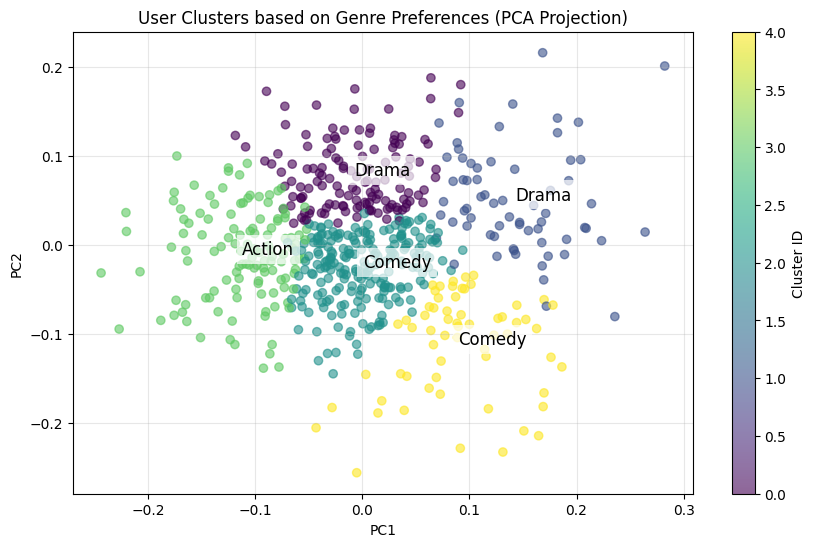

In [3]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Merge Ratings and Movies to get Genres
if 'movies' in locals() and 'ratings' in locals():
    data = pd.merge(ratings, movies, on='movieId')
    
    # 2. Extract Genres (One-Hot Encoding)
    # Split genres 'Action|Adventure' -> ['Action', 'Adventure']
    data['genres'] = data['genres'].apply(lambda x: x.split('|'))
    # Explode to have one row per genre-user interaction
    data_exploded = data.explode('genres')
    
    # 3. Create User-Genre Matrix (Count of movies watched per genre)
    user_genre_matrix = pd.crosstab(data_exploded['userId'], data_exploded['genres'])
    
    # Normalize row-wise (user profile -> ratio of genres)
    user_genre_norm = user_genre_matrix.div(user_genre_matrix.sum(axis=1), axis=0)
    
    # 4. Clustering (K-Means)
    n_clusters = 5
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(user_genre_norm)
    
    # 5. Dimensionality Reduction (PCA) for Visualization
    pca = PCA(n_components=2)
    reduced_features = pca.fit_transform(user_genre_norm)
    
    # 6. Plotting
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(reduced_features[:, 0], reduced_features[:, 1], 
                          c=clusters, cmap='viridis', alpha=0.6)
    plt.title('User Clusters based on Genre Preferences (PCA Projection)')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.colorbar(scatter, label='Cluster ID')
    plt.grid(True, alpha=0.3)

    # Annotate clusters with dominant genre
    # For each cluster, find the genre with the highest mean weight
    user_genre_norm['cluster'] = clusters
    cluster_profiles = user_genre_norm.groupby('cluster').mean()
    
    for i in range(n_clusters):
        dominant_genre = cluster_profiles.loc[i].idxmax()
        # Find center of cluster in PCA space
        center = reduced_features[clusters == i].mean(axis=0)
        plt.text(center[0], center[1], dominant_genre, fontsize=12, 
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
                 
    plt.show()
else:
    print("Movies/Ratings data not loaded. Please run Section 0.")

### 1.2 Real-World Reward Landscape

Now that we have identified user clusters, we can calculate the **Reward Landscape**. This represents the probability (or average rating) that a user from a specific cluster will like a specific item.

The following code:
1.  Selects the **Top 20 most rated movies** to represent the Action Space.
2.  Calculates the **Average Rating** for each of these movies within each User Cluster.
3.  Visualizes this as a Heatmap, which serves as the "Ground Truth" environment for our agents.

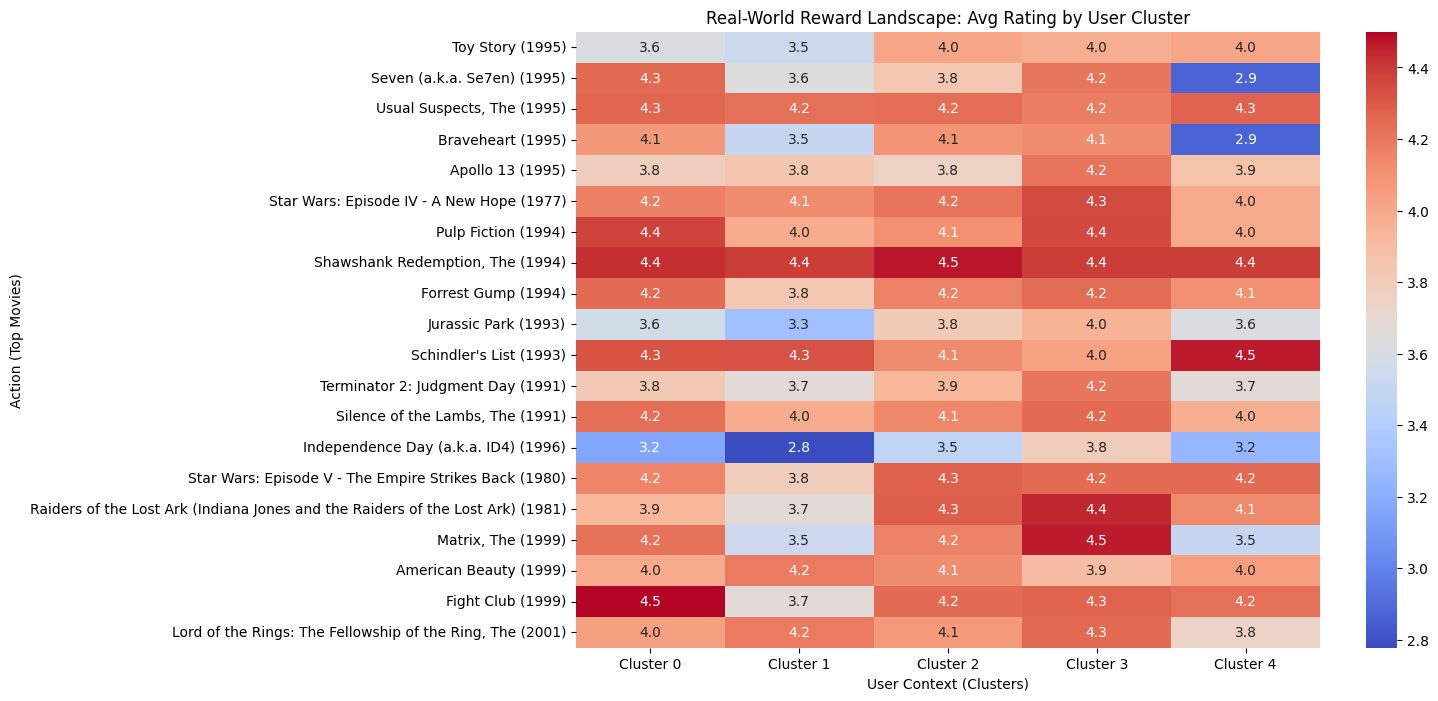

In [4]:
# 1. Select Action Space (Top 20 Movies)
if 'ratings' in locals() and 'movies' in locals() and 'user_genre_norm' in locals():
    # We need 'cluster' column in user_genre_norm. It was added in previous cell.
    # Also need to map users to clusters in the ratings dataframe
    
    # Get mapping: userId -> cluster
    # user_genre_norm index is userId
    user_cluster_map = user_genre_norm['cluster']
    
    # Merge cluster info into ratings
    ratings_with_cluster = ratings.join(user_cluster_map, on='userId', how='inner')
    
    # Identify Top 20 Movies by number of ratings
    top_movies_ids = ratings['movieId'].value_counts().head(20).index
    top_movies = movies[movies['movieId'].isin(top_movies_ids)].set_index('movieId')
    # Re-order by popularity for better visualization
    top_movies = top_movies.loc[top_movies_ids]
    
    # 2. Calculate Reward Matrix (Avg Rating per Cluster per Movie)
    # Filter ratings for top movies
    relevant_ratings = ratings_with_cluster[ratings_with_cluster['movieId'].isin(top_movies_ids)]
    
    # Group by [movieId, cluster] and mean(rating)
    reward_matrix = relevant_ratings.groupby(['movieId', 'cluster'])['rating'].mean().unstack()
    
    # Fill NaNs with global average or 0 (if a cluster never rated a top movie)
    reward_matrix = reward_matrix.fillna(relevant_ratings['rating'].mean())
    
    # 3. Visualization
    plt.figure(figsize=(12, 8))
    sns.heatmap(reward_matrix, cmap='coolwarm', annot=True, fmt=".1f",
                xticklabels=[f"Cluster {i}" for i in range(reward_matrix.shape[1])],
                yticklabels=[top_movies.loc[mid, 'title'] for mid in reward_matrix.index])
    plt.title('Real-World Reward Landscape: Avg Rating by User Cluster')
    plt.xlabel('User Context (Clusters)')
    plt.ylabel('Action (Top Movies)')
    plt.show()
else:
    print("Previous cells must be run to define 'ratings', 'movies', and 'user_genre_norm'.")

## 2. Experiment Protocols

To ensure scientific rigor, we defined three standard protocols in `src/experiments/protocols.py`. Each protocol tests a specific aspect of the User-Recommender interaction.

| Protocol | Name | Description | Key Metric |
| :--- | :--- | :--- | :--- |
| **A** | **Stationary Baseline** | Standard RL setup. No psychological modulation. Fixed environment. | **Convergence Time**: How fast does the agent find the optimal items? |
| **B** | **Modulated Learning** | Initializes psychological modulators (e.g., Boredom). The user's reward perception changes based heavily on history. | **Suboptimality Gap**: Does the user get "stuck" accepting worse items because of their internal state? |
| **C** | **Non-Stationary** | The environment itself changes over time (e.g., user preferences drift naturally). | **Tracking Error**: Can the recommender keep up with the changing user? |

### Example Configuration
Here is how these protocols are configured in code:

In [5]:
from dataclasses import dataclass

# Simplified representation of the Protocol Config structure
@dataclass
class ProtocolConfig:
    name: str
    modulator_active: bool
    environment_static: bool

protocols = {
    "A": ProtocolConfig("Stationary", modulator_active=False, environment_static=True),
    "B": ProtocolConfig("Modulated", modulator_active=True, environment_static=True),
    "C": ProtocolConfig("Non-Stationary", modulator_active=False, environment_static=False)
}

for key, p in protocols.items():
    print(f"Protocol {key}: {p.name} -> Modulator: {p.modulator_active}, Static Env: {p.environment_static}")

Protocol A: Stationary -> Modulator: False, Static Env: True
Protocol B: Modulated -> Modulator: True, Static Env: True
Protocol C: Non-Stationary -> Modulator: False, Static Env: False


## 3. Markov Chain Analysis

We model the entire interaction as a **Markov Chain**. 

### What is the "State"?
The state of the system is complex. It represents the combination of:
1.  **User's Beliefs**:Represented by their Q-values (what they think is good).
2.  **Recommender's Beliefs**: Represented by their Q-values (what they think the user likes).
3.  **Modulator State**: E.g., current "boredom" level.
4.  **Context**: The current user cluster active in the environment.

### Why Markov Chains?
By treating simulations as trajectories through this state space, we can mathematically analyze:
*   **Absorption**: Does the system settle into a permanent loop (e.g., Filter Bubble)?
*   **Mixing Time**: How long generally does it take to stabilize?
*   **Ergodicity**: Can the system reach any state from any other state, or are some regions "walled off"?

### Visualization: Convergence Trajectory
We track the "distance" between states over time. As the agents learn, the system state should change less and less, eventually approaching zero (Absorption).

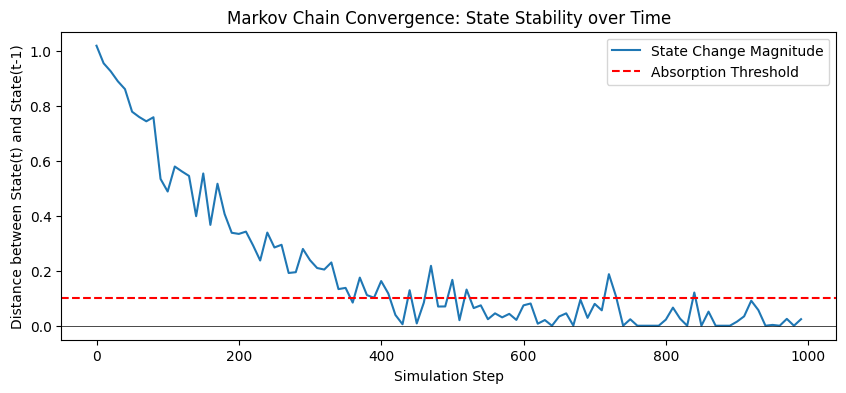

In [6]:
import matplotlib.pyplot as plt

# Simulated convergence data
steps = np.arange(0, 1000, 10)
# Distance between consecutive states decreases as agents learn
state_deltas = np.exp(-steps / 200) + np.random.normal(0, 0.05, len(steps))
state_deltas = np.clip(state_deltas, 0, None)

plt.figure(figsize=(10, 4))
plt.plot(steps, state_deltas, label="State Change Magnitude")
plt.axhline(0, color='black', linewidth=0.5)
plt.axhline(0.1, color='red', linestyle='--', label="Absorption Threshold")
plt.title("Markov Chain Convergence: State Stability over Time")
plt.xlabel("Simulation Step")
plt.ylabel("Distance between State(t) and State(t-1)")
plt.legend()
plt.show()